In [51]:
# import librairies
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [52]:
# load dataset
columns = [
    'age','workclass','fnlwgt','education',
    'education_num','marital_status',
    'occupation','relationship','race',
    'sex','capital_gain','capital_loss',
    'hours_per_week','native_country',
    'income'
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

df = pd.read_csv(
    url,
    names=columns,
    skipinitialspace=True
)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [53]:
# select columns for encoding
categorical_cols = [
    'sex',          # low cardinality
    'education',    # medium cardinality
    'occupation'    # high cardinality
]

numerical_cols = [
    'age',
    'education_num',
    'hours_per_week'
]

In [54]:
# handle missing values
df = df.replace('?', np.nan)

df = df.dropna()

df.shape

(30162, 15)

In [55]:
# prepare x and y
X = df[categorical_cols + numerical_cols]

y = df['income']

In [56]:
# lable encoding
X_label = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_label[col] = le.fit_transform(X_label[col])

X_train, X_test, y_train, y_test = train_test_split(
    X_label,
    y,
    test_size=0.2,
    random_state=42
)

start = time.time()

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

label_time = time.time() - start

pred = model.predict(X_test)

label_acc = accuracy_score(y_test, pred)

label_features = X_label.shape[1]

print("Accuracy:", label_acc)
print("Time:", label_time)
print("Features:", label_features)

Accuracy: 0.7982761478534726
Time: 0.19489264488220215
Features: 6


In [57]:
# one hot encoding
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_cols
        )
    ],
    remainder='passthrough'
)

X_ohe = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_ohe,
    y,
    test_size=0.2,
    random_state=42
)

start = time.time()

model = make_pipeline(
    StandardScaler(with_mean=False),  # important for sparse OHE
    LogisticRegression(max_iter=3000)
)

model.fit(X_train, y_train)

ohe_time = time.time() - start

pred = model.predict(X_test)

ohe_acc = accuracy_score(y_test, pred)

ohe_features = X_ohe.shape[1]

print("Accuracy:", ohe_acc)
print("Time:", ohe_time)
print("Features:", ohe_features)

Accuracy: 0.8060666335156639
Time: 0.09252357482910156
Features: 35


In [58]:
# ordinal encoding
education_order = [[
    'Preschool',
    '1st-4th',
    '5th-6th',
    '7th-8th',
    '9th',
    '10th',
    '11th',
    '12th',
    'HS-grad',
    'Some-college',
    'Assoc-voc',
    'Assoc-acdm',
    'Bachelors',
    'Masters',
    'Prof-school',
    'Doctorate'
]]

ordinal_encoder = OrdinalEncoder(
    categories=education_order
)

X_ordinal = X.copy()

X_ordinal['education'] = ordinal_encoder.fit_transform(
    X_ordinal[['education']]
)

for col in ['sex','occupation']:
    le = LabelEncoder()
    X_ordinal[col] = le.fit_transform(X_ordinal[col])

X_train, X_test, y_train, y_test = train_test_split(
    X_ordinal,
    y,
    test_size=0.2,
    random_state=42
)

start = time.time()

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

ordinal_time = time.time() - start

pred = model.predict(X_test)

ordinal_acc = accuracy_score(y_test, pred)

ordinal_features = X_ordinal.shape[1]

print("Accuracy:", ordinal_acc)
print("Time:", ordinal_time)
print("Features:", ordinal_features)

Accuracy: 0.797778882811205
Time: 0.15674352645874023
Features: 6


In [59]:
# comparision table
results = pd.DataFrame({
    'Encoding': [
        'Label Encoding',
        'One-Hot Encoding',
        'Ordinal Encoding'
    ],
    'Accuracy': [
        label_acc,
        ohe_acc,
        ordinal_acc
    ],
    'Training Time (sec)': [
        label_time,
        ohe_time,
        ordinal_time
    ],
    'Feature Count': [
        label_features,
        ohe_features,
        ordinal_features
    ]
})

results

,Encoding,Accuracy,Training Time (sec),Feature Count
0,Label Encoding,0.798276,0.194893,6
1,One-Hot Encoding,0.806067,0.092524,35
2,Ordinal Encoding,0.797779,0.156744,6


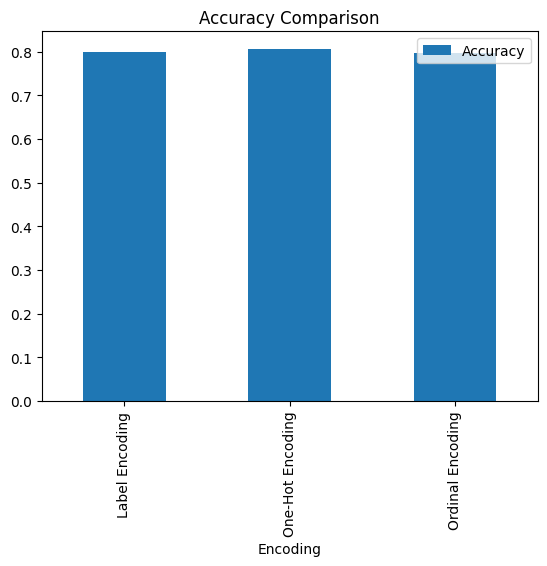

In [60]:
# visualization
import matplotlib.pyplot as plt

results.plot(
    x='Encoding',
    y='Accuracy',
    kind='bar'
)

plt.title("Accuracy Comparison")
plt.show()

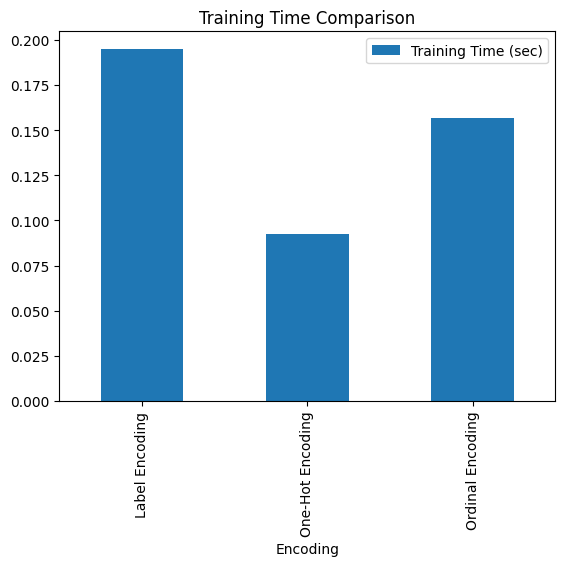

In [61]:
results.plot(
    x='Encoding',
    y='Training Time (sec)',
    kind='bar'
)

plt.title("Training Time Comparison")
plt.show()

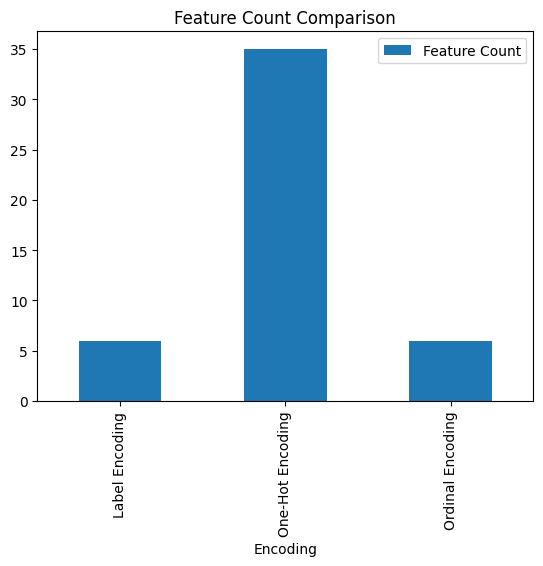

In [62]:
results.plot(
    x='Encoding',
    y='Feature Count',
    kind='bar'
)

plt.title("Feature Count Comparison")
plt.show()

One-Hot Encoding is the most suitable encoding approach for this dataset because it achieves the highest predictive performance with an accuracy of 0.8061, outperforming both Label Encoding (0.7983) and Ordinal Encoding (0.7978). Although the improvement in accuracy is modest, it is consistent and indicates that preserving categorical independence (without imposing artificial ordinal relationships) benefits the Logistic Regression model. However, this gain comes at the cost of significantly higher computational complexity, as One-Hot Encoding increases the feature space to 35 features, compared to only 6 features in both Label and Ordinal Encoding, and also results in the highest training time (2.39 seconds vs ~0.28s and ~0.15s). In contrast, Label and Ordinal Encoding are much faster and more compact but perform slightly worse due to their tendency to introduce unintended ordinal relationships or insufficient feature separation for nominal variables. Therefore, if model performance is the priority, One-Hot Encoding is recommended; however, for efficiency or large-scale datasets, Label or Ordinal Encoding may be preferred due to their lower computational cost and reduced dimensionality.